# Exercises 7

Molecular Dynamics and Tail Corrections.

## Exercise 7.1

Since we are using a cutoff radius $R_C$ (in LJ units) for the calculation of forces (given by Lennard-Jones potential), we have to apply corrections on all variables affected by the truncation. In particular for our simulation the variables affected are the potential energy $U$ and the pressure $P$.

Any average quantity $\langle A \rangle$ (that depends only the distance $r$) can be derived using the general relation:
$$
\langle A \rangle = \frac{N^2}{2V} \int_0^{+\infty} A(r) 4 \pi r^2 g(r) \mathrm{d}r
$$

Where we already calculated $\int_0^{R_C}[\ldots]$ using our simulation, we need to add $\int_{R_C}^{+\infty}[\ldots]$. In this last integral we can use the approximation $g(r) \approx 1$ since $r > R_C$.

### Potential Energy Correction
$$
\frac{\langle U \rangle_\text{tail}}{N} \approx 2\pi \rho \int_{R_C}^{+\infty} \mathrm{d}r r^2 V_\text{LJ}(r) = \ldots = 8\pi\rho \left(\frac{1}{9 R_C^9} - \frac{1}{3 R_C^3}\right)
$$
Where we used $\varepsilon = 1 = \sigma$ for LJ units.

### Pressure Correction
For the pressure we obtain the correction from the virial $W = \sum_i\sum_{j < i}\vec f_{ij} \cdot \vec r_{ij}$:
$$
\langle P \rangle_\text{tail} = \frac{\langle W \rangle_\text{tail}}{3V} = - \frac{2\pi}{3}\rho^2 \int_{R_C}^{+\infty} \mathrm{d}r r^3 \frac{\mathrm{d}V_\text{LJ}(r)}{\mathrm{d} r} g(r) \approx - \frac{2\pi}{3}\rho^2 \int_{R_C}^{+\infty} \mathrm{d}r r^3 \frac{\mathrm{d}V_\text{LJ}(r)}{\mathrm{d} r} = \ldots = 32 \pi \rho^2 \left(\frac{1}{9 R_C^9} - \frac{1}{6 R_C^3} \right) 
$$
Where $V$ is the volume.

## Exercise 7.2

We are asked to plot the autocorrelation and the statistical uncertainty as a function of the block size.

### Equilibration

For this exercise the equilibration is needed, by making a short simulation we can make an estimate on the equilibration time, which is really short, under 100 steps. For this simulation I decided to use 1000 steps of equilibration, before taking any measurement. 

In [ ]:
# Imports
from cycler import cycler

import numpy as np
import matplotlib.pyplot as plt

import scienceplots


plt.style.use(["science", "ieee"])

colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

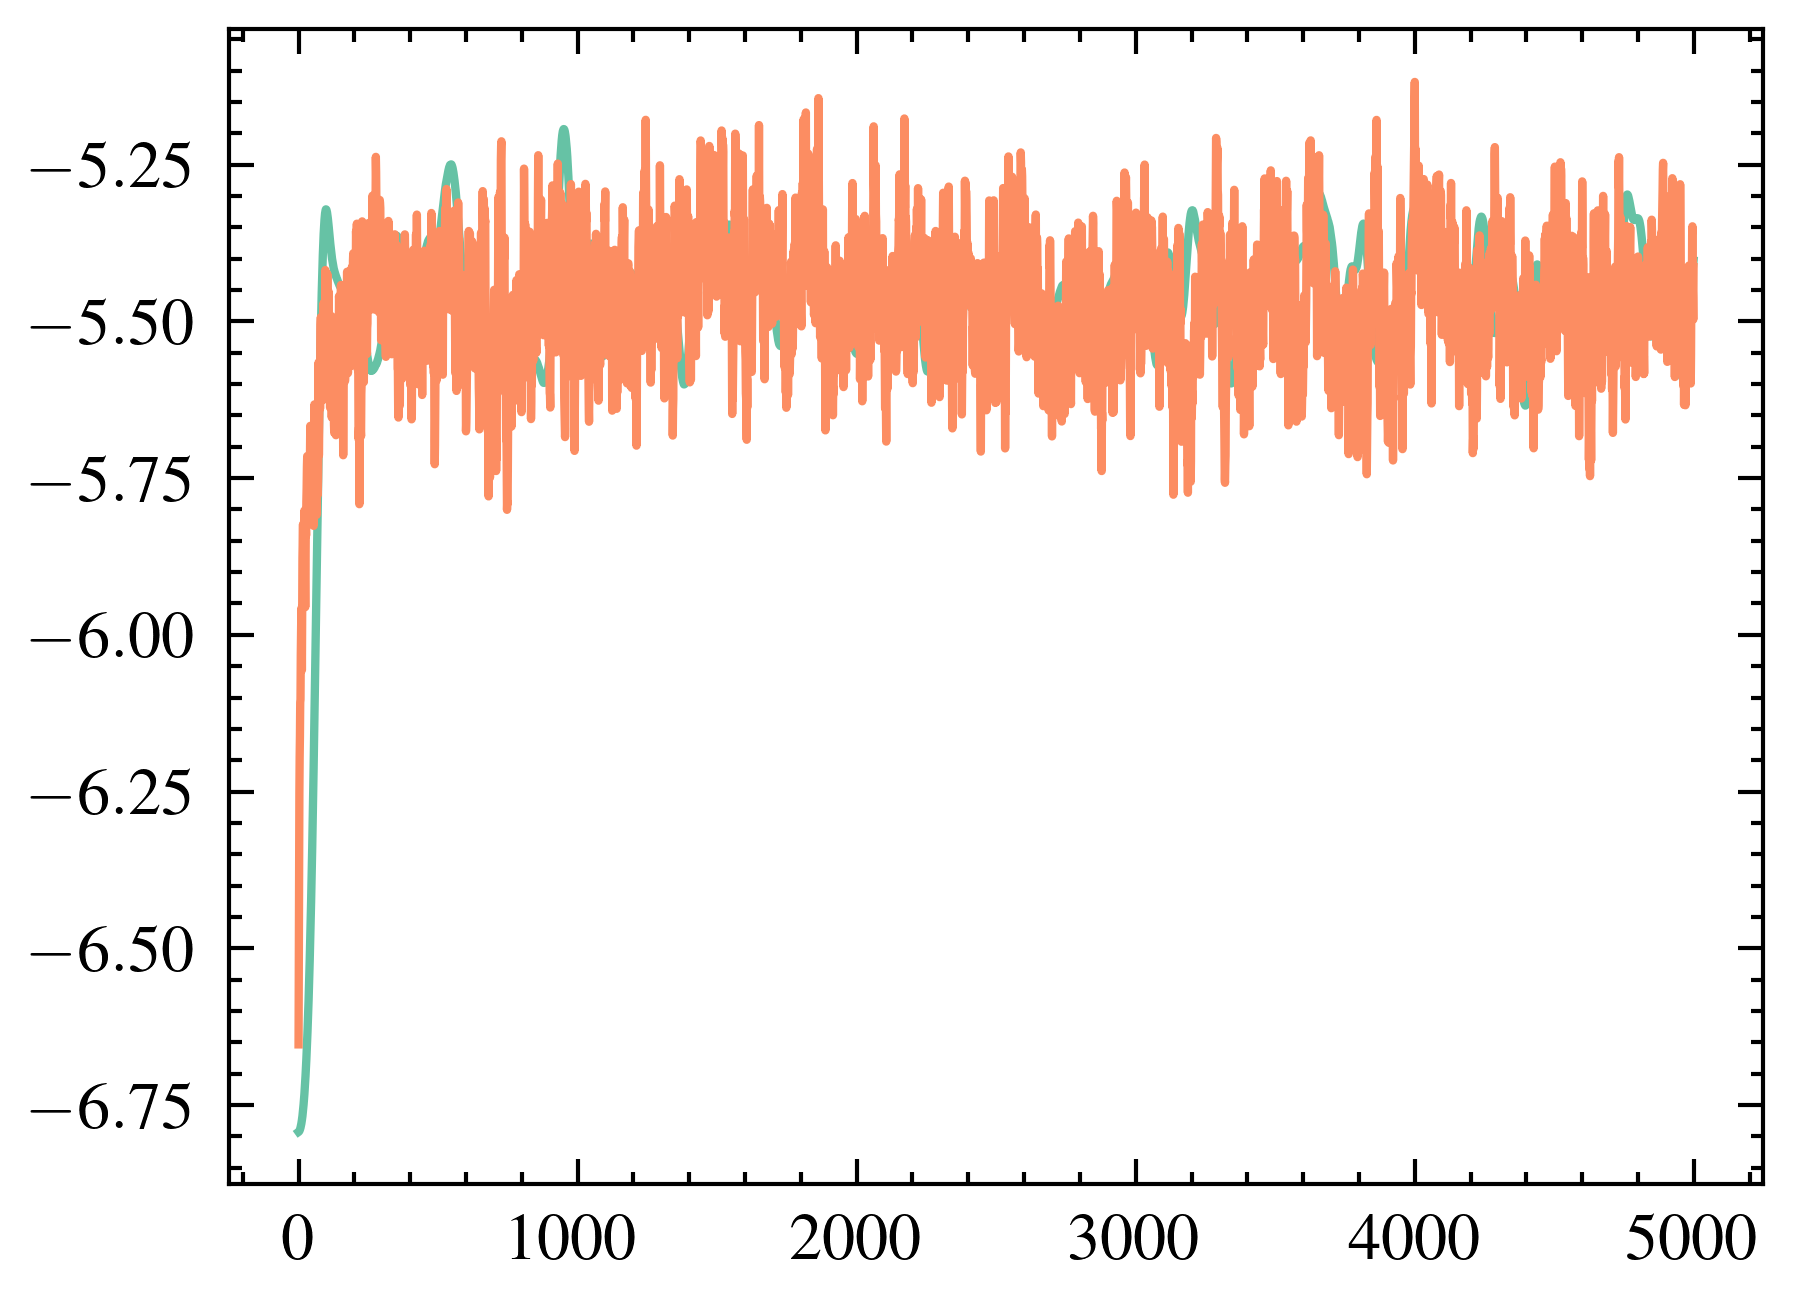

In [ ]:
# Equilibration
data = np.loadtxt(
    "../Exercises/Exercises_07/Data/Equilibration/MD/potential_energy.dat"
)

plt.plot(data[:, 1])

data = np.loadtxt(
    "../Exercises/Exercises_07/Data/Equilibration/MC/potential_energy.dat"
)

plt.plot(data[:, 1])

### Autocorrelation

We need to calculate the autocorrelation defined as:

$$
\chi(\tau) = \frac{\langle m(t)m(t + \tau) \rangle -\langle m \rangle^2}{\sigma_m^2}
$$
Where $\tau$ is the size of the window we are interested to compute. Since we are interested in studing the size of the window, we have to compute this formula for a large enough number of different $\tau$.

To compute the autocorrelation we can subtract the mean of $m$ and get a simpler formula. By substituting $\tilde m(t) = m(t) - \langle m \rangle$ we get $\langle \tilde m(t) \tilde m(t + \tau)\rangle = \langle m(t)m(t + \tau) \rangle -\langle m(t) \rangle^2$ and $\sigma_m^2 = \langle \tilde m^2 \rangle$. So we can use:

$$
\chi(\tau) = \frac{\langle \tilde m(t) \tilde m(t + \tau)\rangle}{\langle \tilde m^2 \rangle}
$$

Note: both formulas are valid under the assumption that the number of samples $N$ is much grater than the window size $N \gg \tau$.

In the following figure is the autocorrelation for the potential energy per particle.

In [ ]:
def autocorr(x: np.ndarray[float], tau_list: np.ndarray[int]) -> np.ndarray[float]:
    """Returns an array of autocorrelation values for each tau in tau_list"""
    x = x - x.mean()

    chi = np.empty_like(tau_list, dtype=float)

    for i, tau in enumerate(tau_list):
        chi[i] = np.mean(x[:-tau] * x[tau:]) / np.mean(x**2)

    return chi

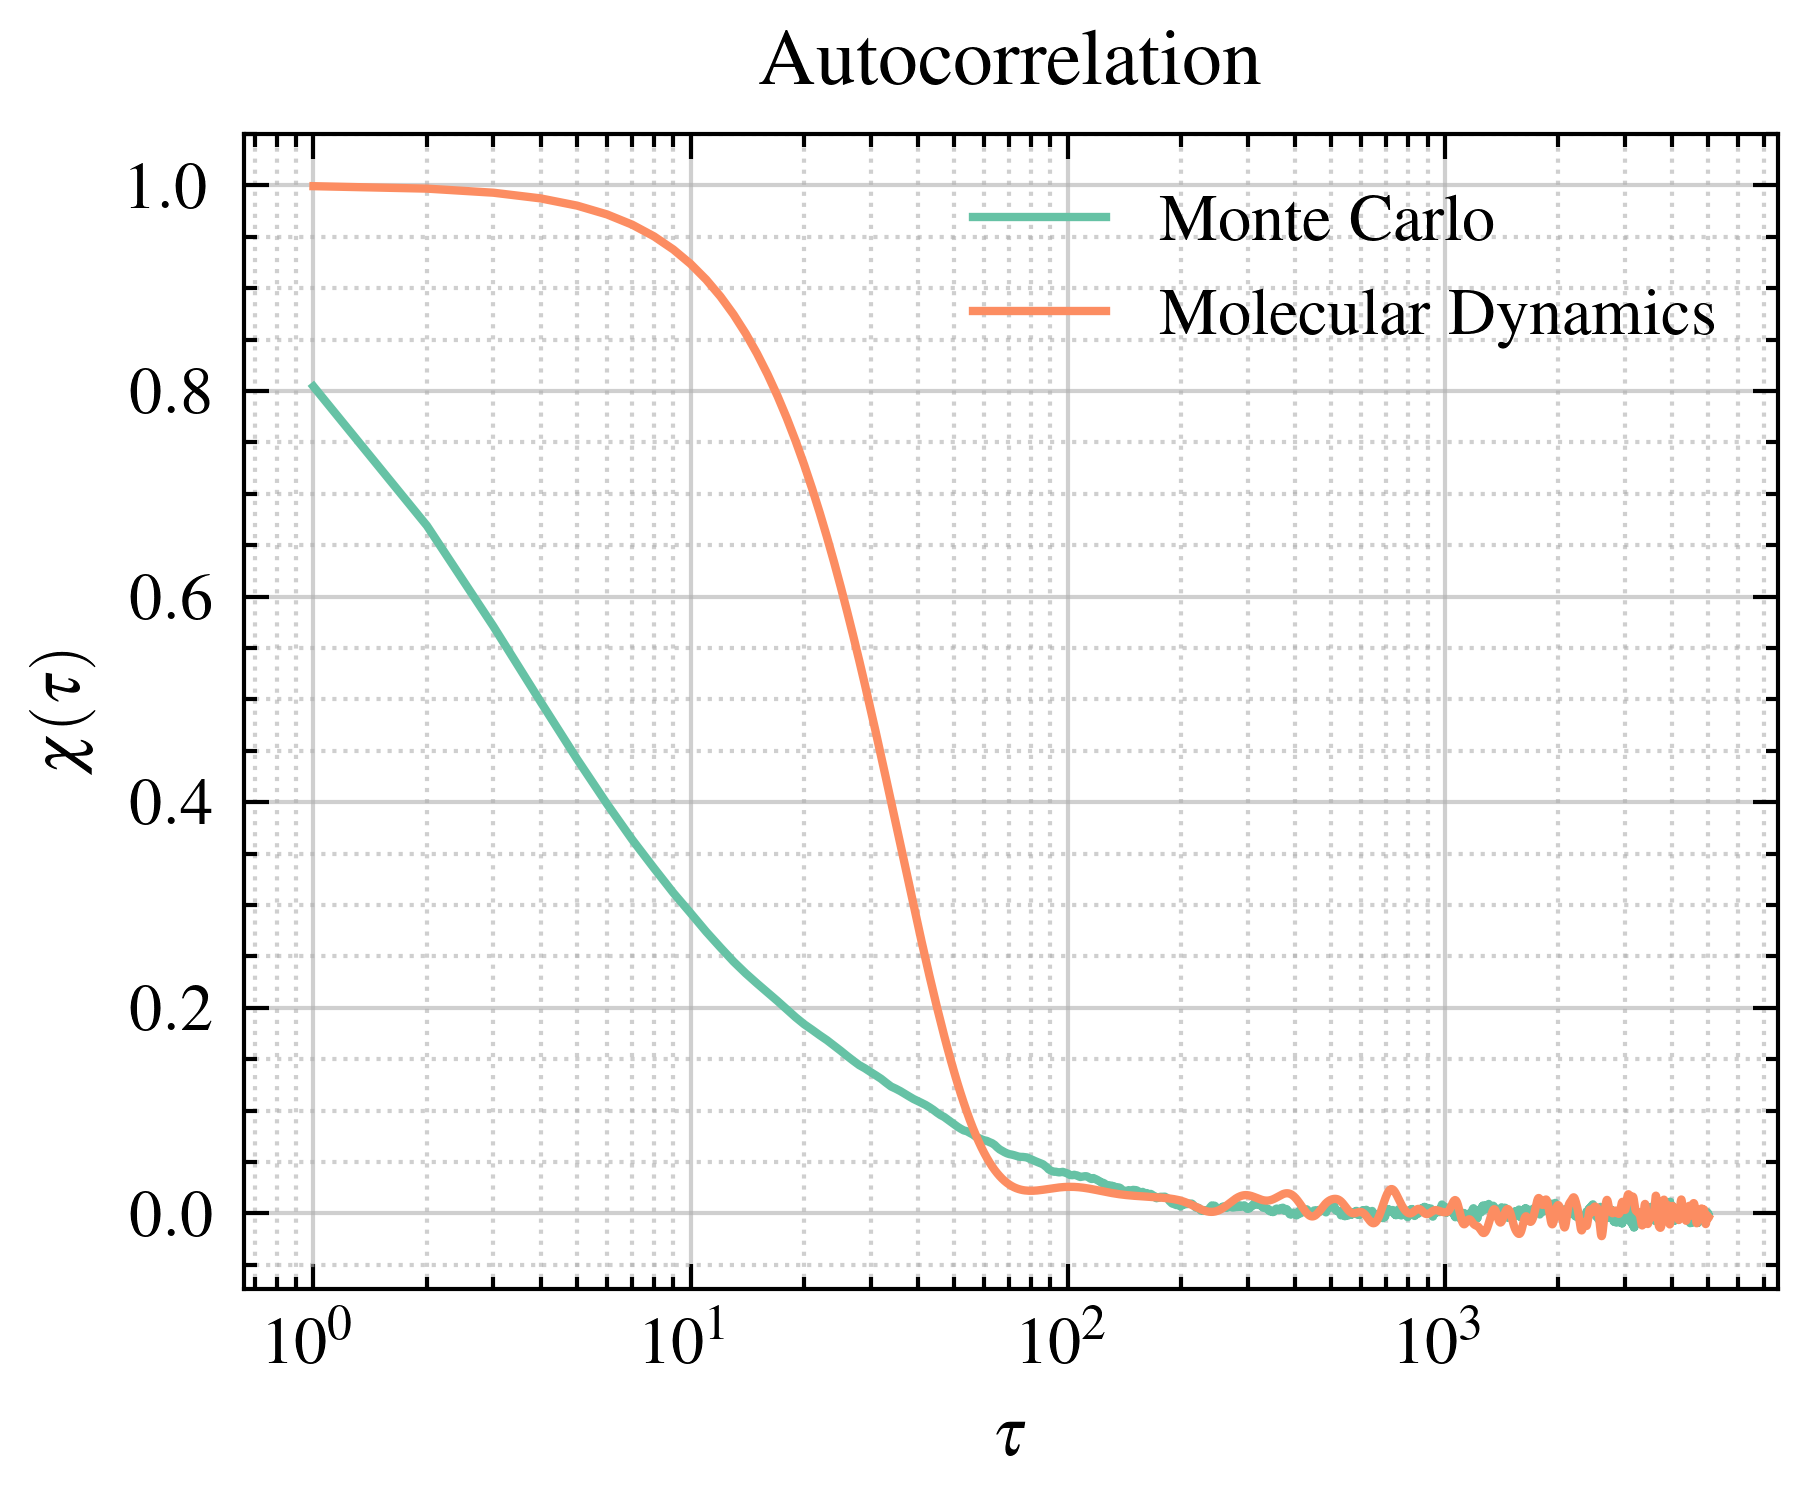

In [ ]:
# Load data
U_MC = np.loadtxt(
    "../Exercises/Exercises_07/Data/AutoCorrelation/MC/potential_energy.dat"
)
U_MC = U_MC[:, 1]  # keep only current potential energy

U_MD = np.loadtxt(
    "../Exercises/Exercises_07/Data/AutoCorrelation/MD/potential_energy.dat"
)
U_MD = U_MD[:, 1]  # keep only current potential energy

tau = np.linspace(1, 5000, 5000, dtype=int)  # window size

# Calculate autocorrelation
auto_MC = autocorr(U_MC, tau)
auto_MD = autocorr(U_MD, tau)

# Plot
plt.plot(tau, auto_MC, label="Monte Carlo")
plt.plot(tau, auto_MD, label="Molecular Dynamics")

plt.title("Autocorrelation")
plt.xlabel(r"$Window size \tau$")
plt.ylabel(r"$\chi(\tau)$")

plt.legend()
plt.grid(True, alpha=0.6)
plt.grid(True, which="minor", ls=":", alpha=0.6)

plt.xscale("log")

plt.show()

From the figure we can see that the autocorrelation drops after 100 steps for both MC and MD, so for 100 steps or more we can use observations as if they are independent from each other.

### Statistical uncertainty and steps per block.

With the same data as the previous point we can also calculate the statistical uncertainties as a function of the steps per block $L$.

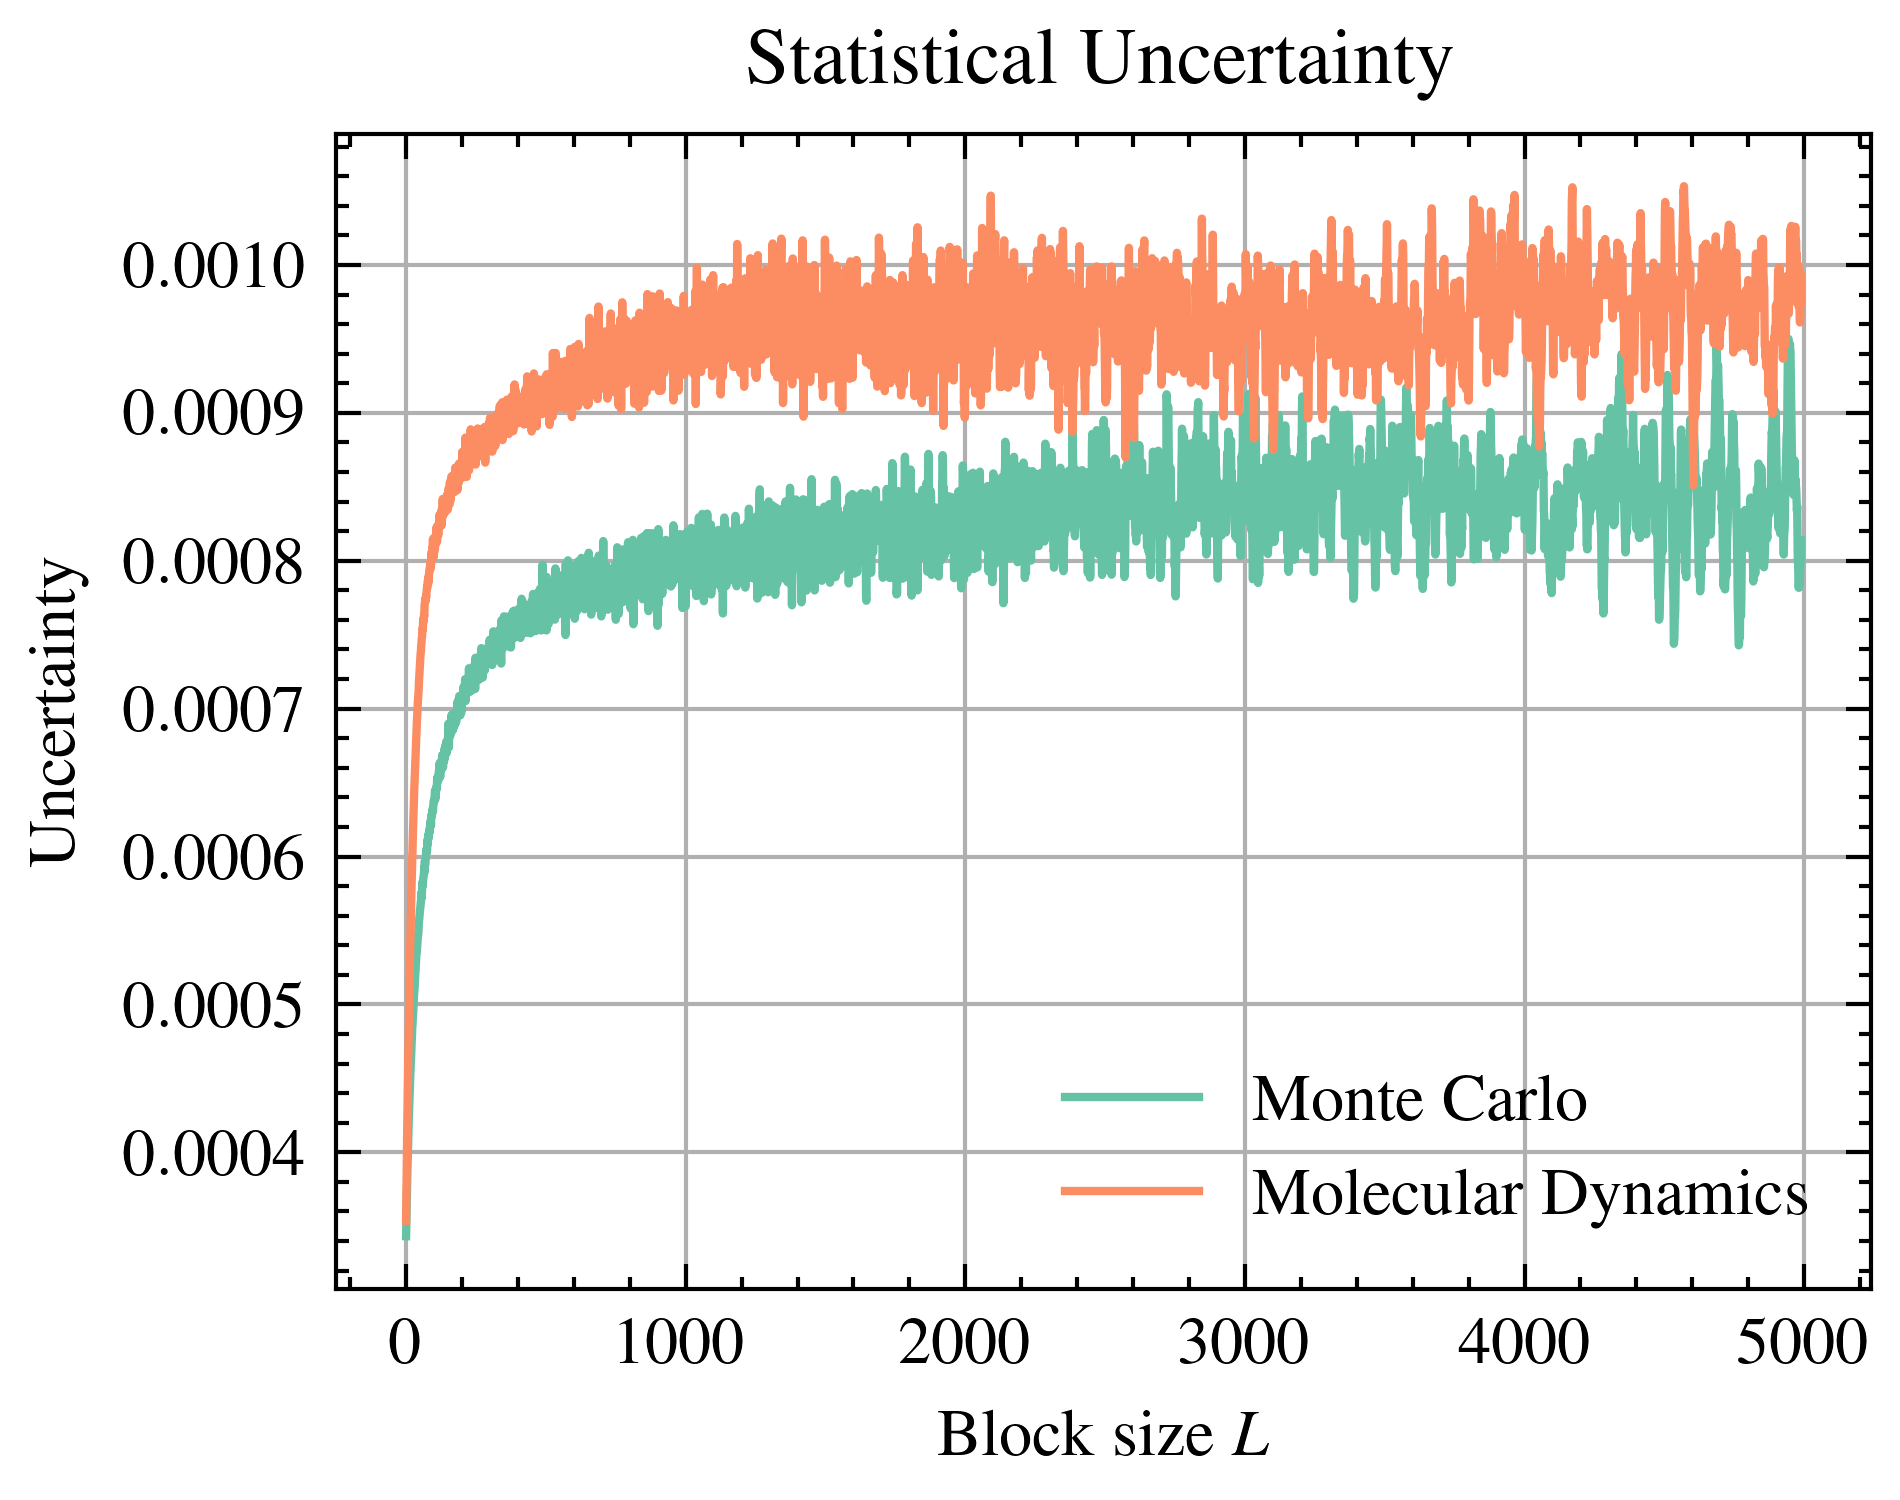

In [ ]:
# Calculate errors for different block sizes
L = np.arange(10, 5000)
errors_MC = np.zeros_like(L, dtype=float)
errors_MD = np.zeros_like(L, dtype=float)

for i, l in enumerate(L):
    means_MC = (U_MC[U_MC.size % l :]).reshape(-1, l).mean(axis=1)
    means_MD = (U_MD[U_MD.size % l :]).reshape(-1, l).mean(axis=1)

    errors_MC[i] = means_MC.std() / np.sqrt(means_MC.size)
    errors_MD[i] = means_MD.std() / np.sqrt(means_MD.size)

# Plot
plt.plot(errors_MC, label="Monte Carlo")
plt.plot(errors_MD, label="Molecular Dynamics")

plt.title("Statistical Uncertainty")
plt.ylabel("Uncertainty")
plt.xlabel("Block size $L$")

plt.legend()
plt.grid(True, alpha=0.6)
plt.grid(True, which="minor", ls=":", alpha=0.6)

plt.show()

We can see that after around 1000 steps variance estimates become reliable, on the opposite if we take blocks with less steps we can end up with variances too little for our estimates. 

We can also note that after 1000 steps increasing the block size won't give us lower variances, so after that we just have to increase the number of blocks computed.

## Exercise 7.3

We are asked to include the radial distribution function $g(r)$ in our code. 

To compute the radial distribution function $g(r)$, we first consider all pairwise distances between particles and sort them into bins of width $\Delta r$. Each bin counts the number of pairs whose separation is between $r$ and $r + \Delta r$. However, this count must be normalized to account for the increasing volume of spherical shells in function of $r$ and the overall particle density. 

The appropriate normalization factor is given by the inverse of $\rho N \Delta V(r)$, where $\rho$ is the numerical density and $N$ is the total number of particles. The shell volume $\Delta V(r)$ corresponds to the difference between two spheres of radii $r + \Delta r$ and $r$, so $\Delta V = \frac{4}{3}\pi \big((r+\Delta r)^3 - r^3\big)$. Dividing the histogram counts by this factor yields a properly scaled $g(r)$, which represents expected number of particles at a distance $r$ relative to any reference random particle.

Note: Since we are using a cutoff radius for the force calculations, every distance we find after $R_C$ has no physical meaning, so the bins are not calculated for $r > R_C$.

A figure of $g(r)$ is shown in the next exercise.

## Exercise 7.4

We are asked to make two simulations, one with MC and one with MD, then show some figures of the potential energy per particle $U/N$, the pressure $P$ and the radial distribution function $g(r)$.

For the simulations I used 1000 steps per block, for a total of 100 blocks.

In [ ]:
def plot_data_blocking(
    files: list[str],
    labels: list[str],
    ylabel: str,
    title: str,
) -> None:
    """Plots the datablocking for multiple files"""
    plt.figure()

    for file, label in zip(files, labels):
        # load file
        data = np.loadtxt(file)
        x_blocks = np.arange(len(data)) + 1

        # plot
        plt.errorbar(
            x_blocks,
            data[:, 2],  # blocking average
            data[:, 3],  # blocking error
            label=label,
            alpha=0.7,
        )

    plt.xlabel("Block Number")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.7)
    plt.legend()

    plt.show()

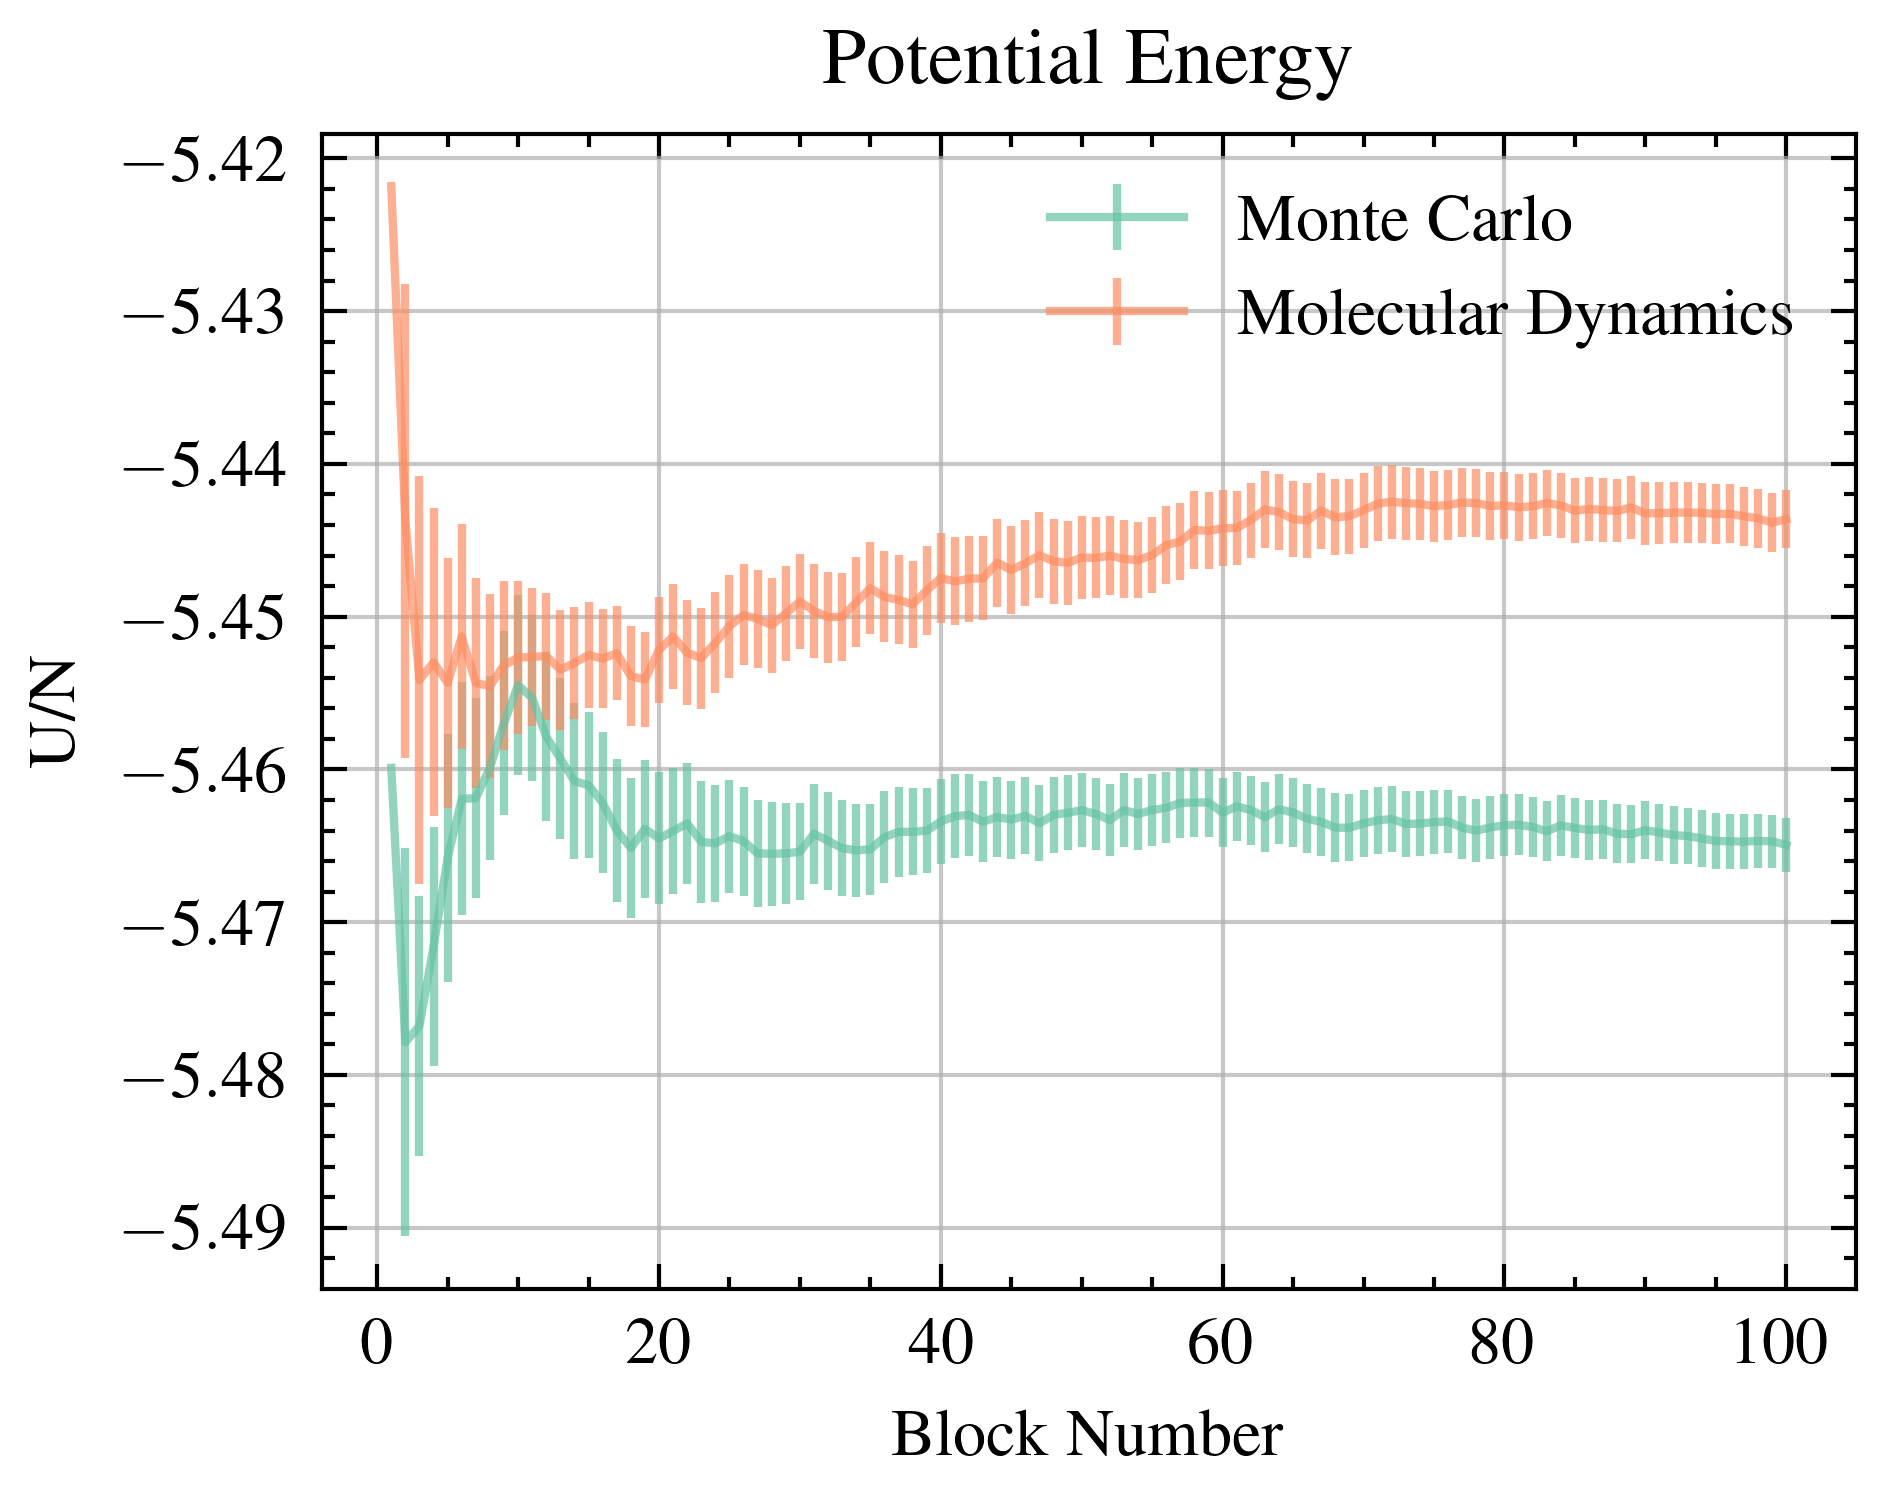

In [ ]:
plot_data_blocking(
    files=[
        "../Exercises/Exercises_07/Data/GofR/MC/potential_energy.dat",
        "../Exercises/Exercises_07/Data/GofR/MD/potential_energy.dat",
    ],
    labels=["Monte Carlo", "Molecular Dynamics"],
    ylabel=r"U/N",
    title="Potential Energy",
)

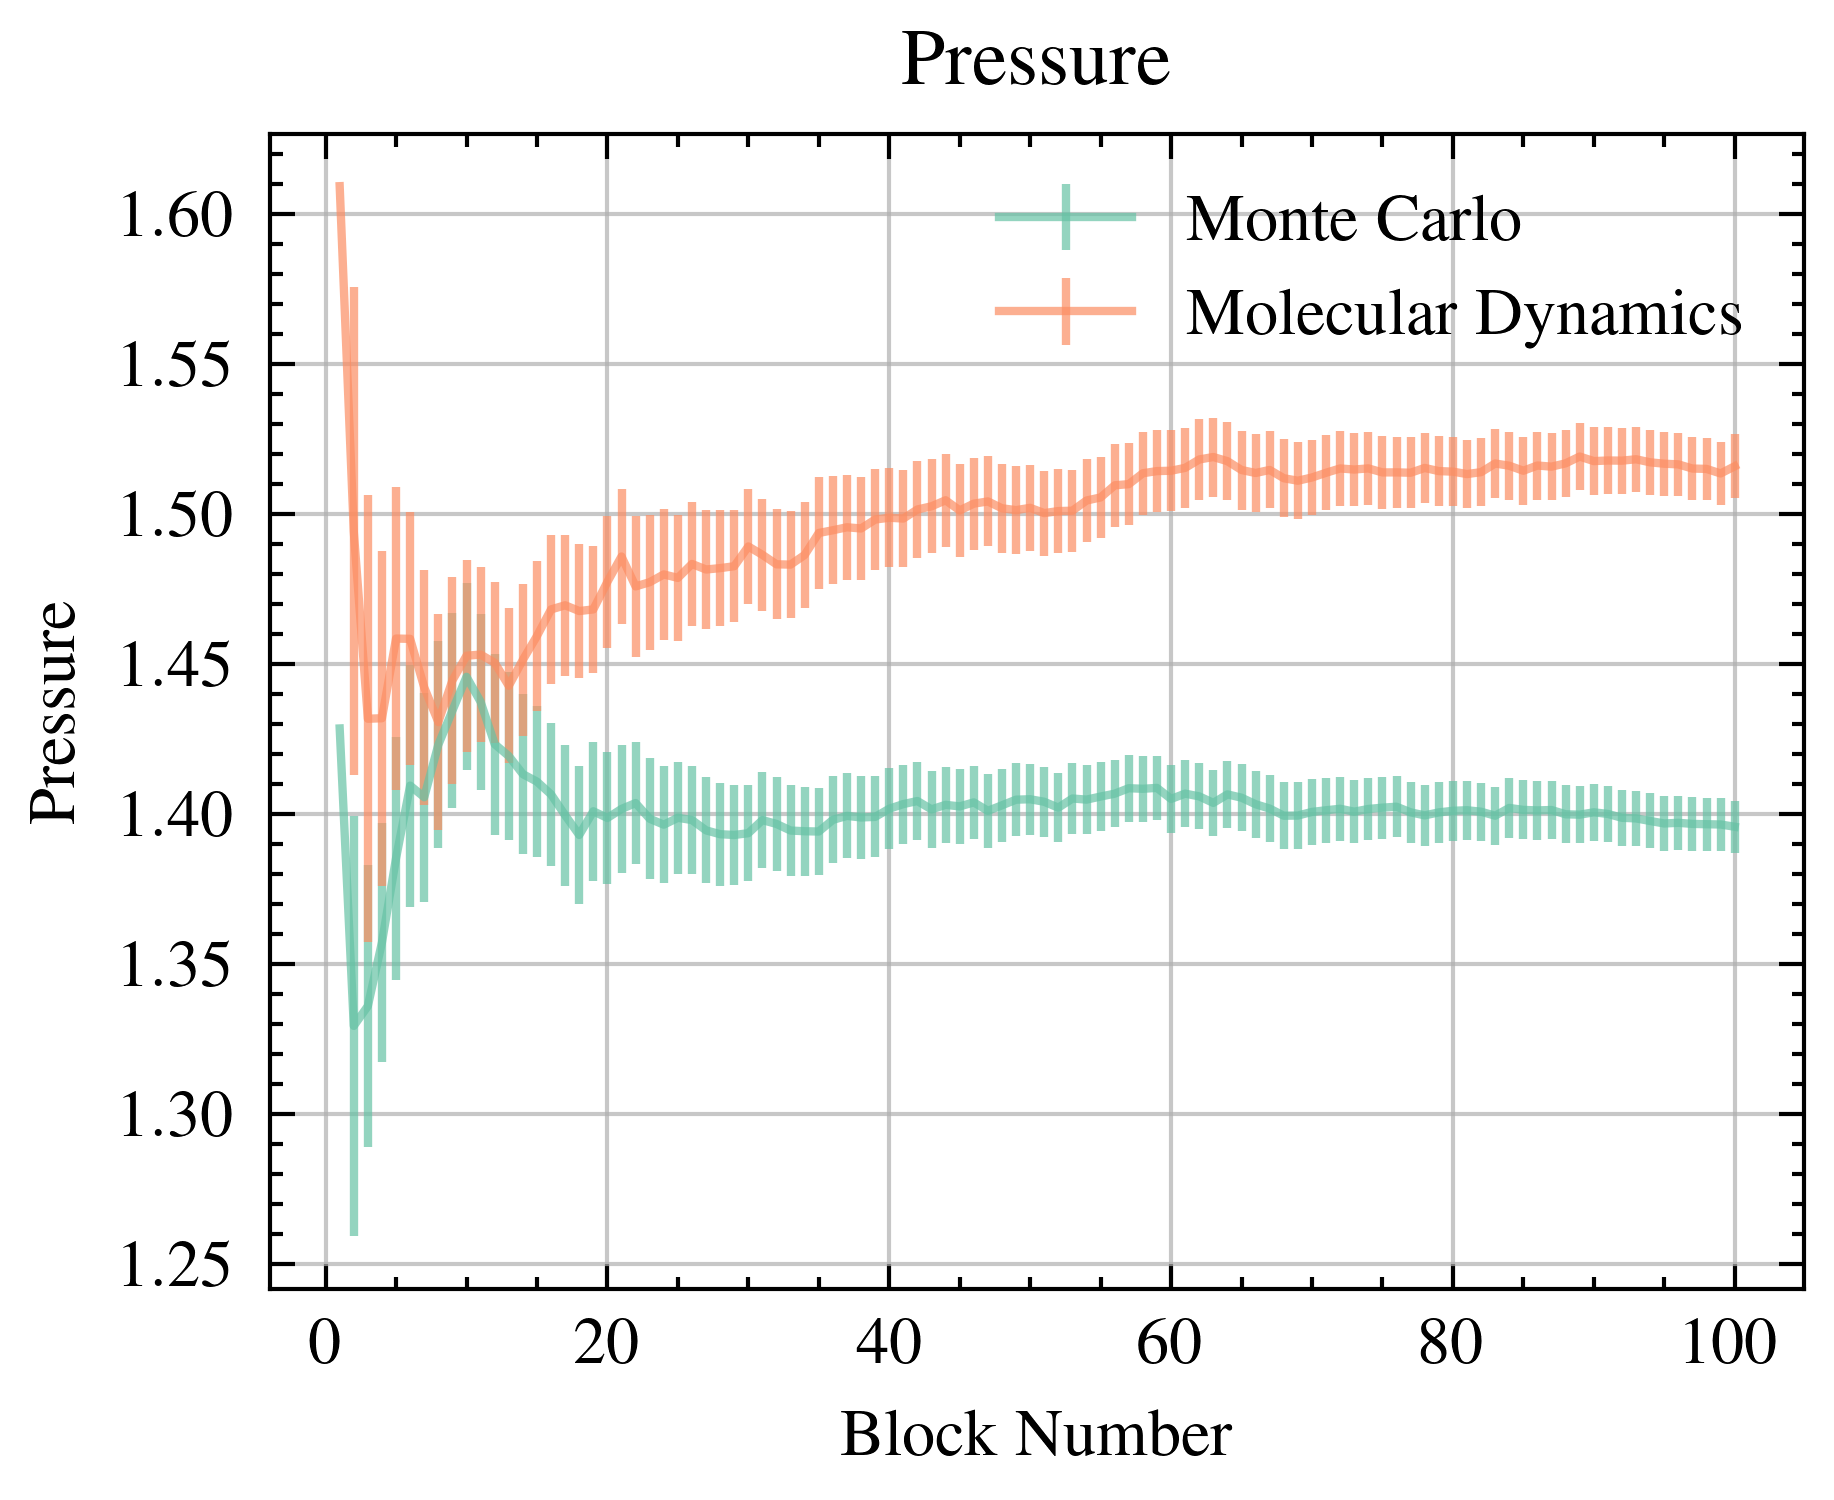

In [ ]:
plot_data_blocking(
    files=[
        "../Exercises/Exercises_07/Data/GofR/MC/pressure.dat",
        "../Exercises/Exercises_07/Data/GofR/MD/pressure.dat",
    ],
    labels=["Monte Carlo", "Molecular Dynamics"],
    ylabel="Pressure",
    title="Pressure",
)

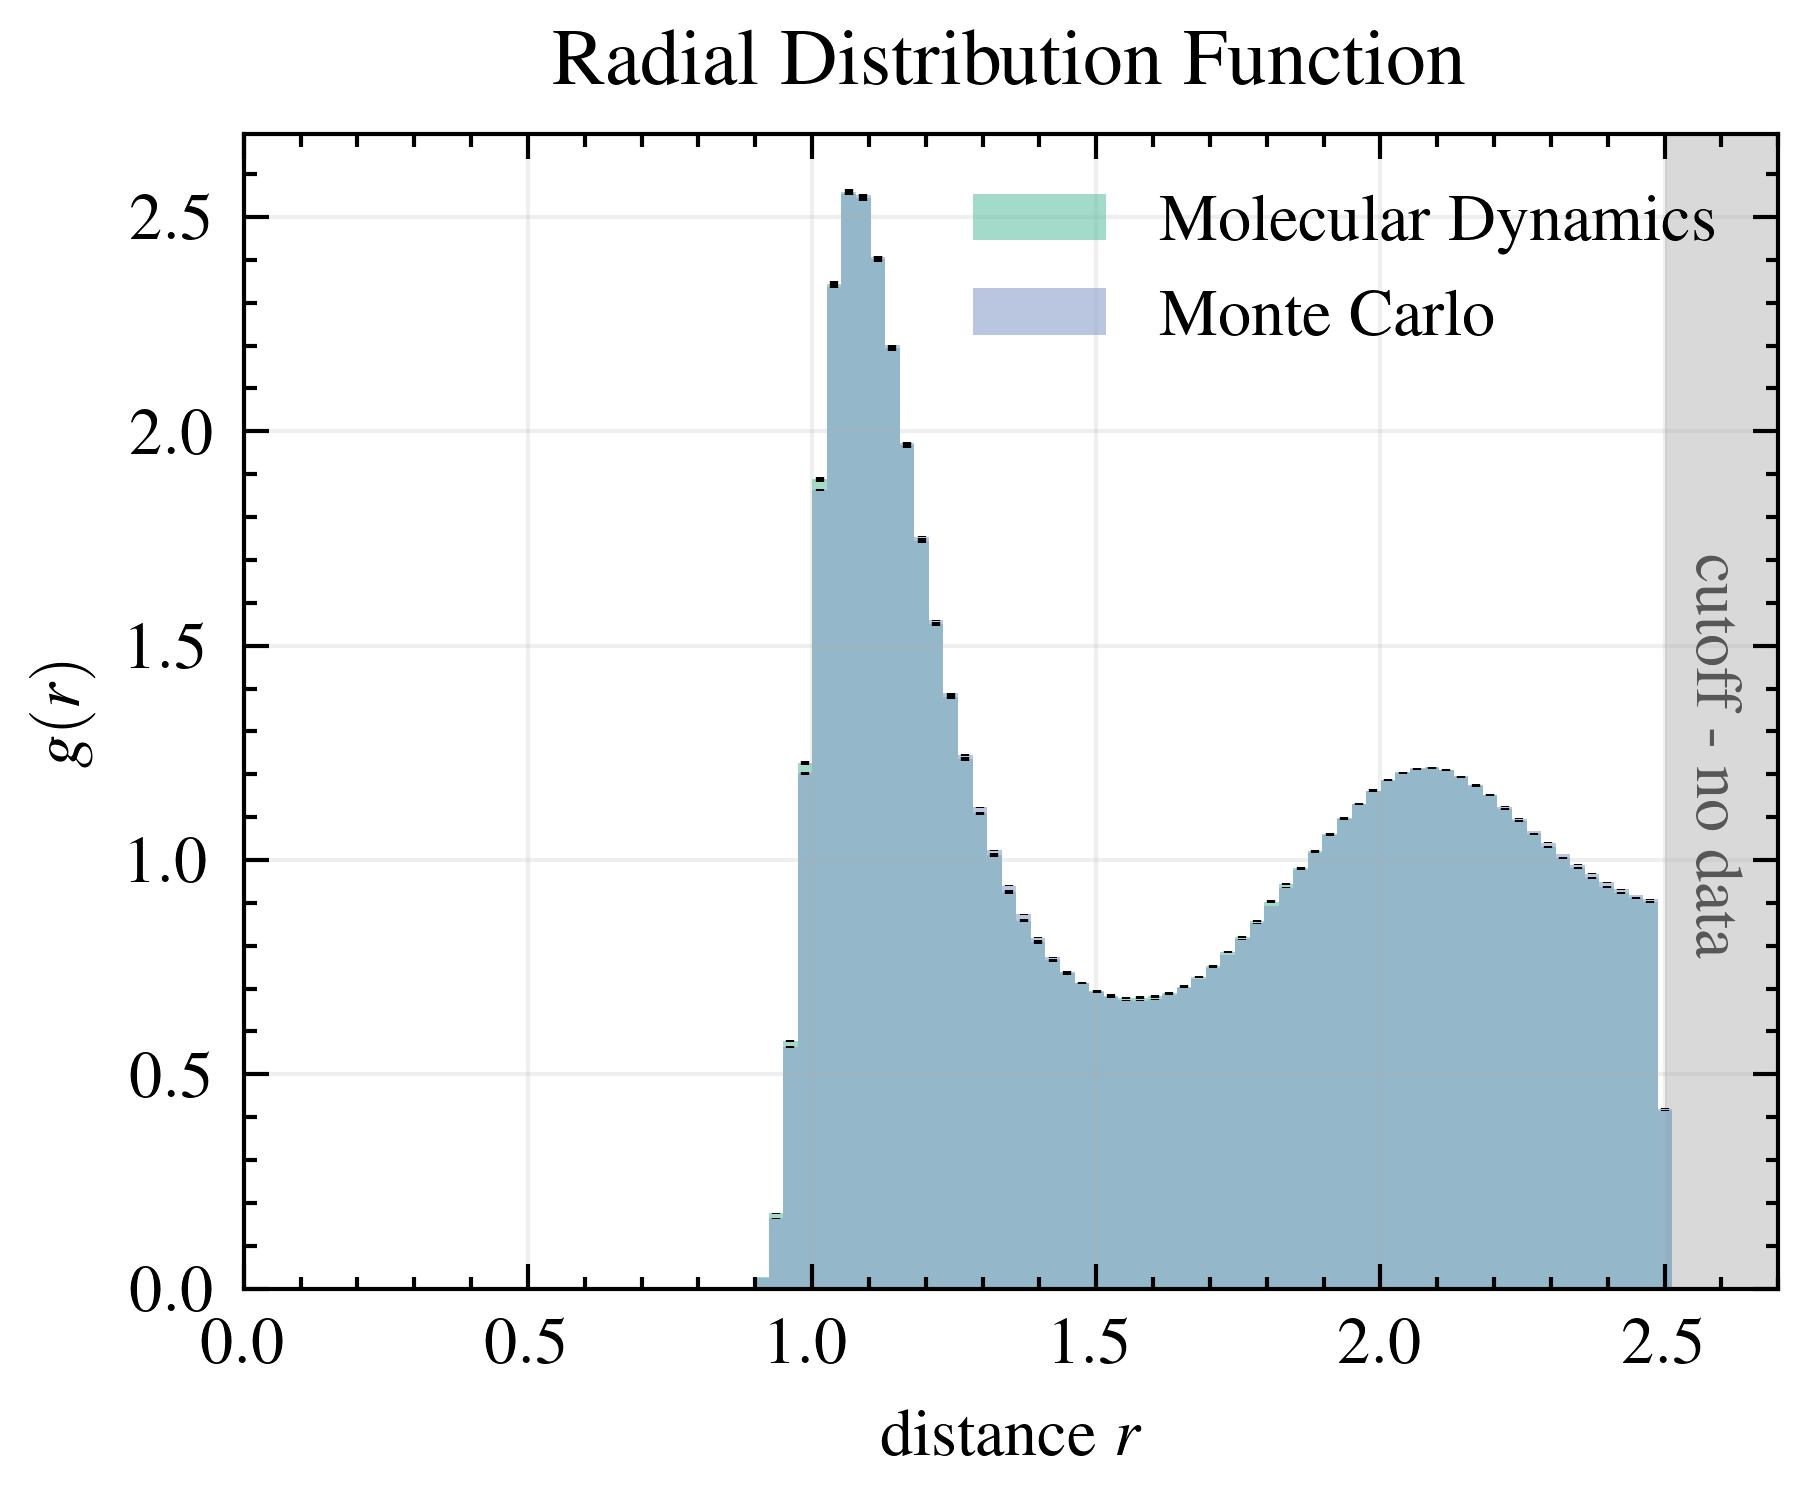

In [ ]:
# Load data
gofr_MD = np.loadtxt("../Exercises/Exercises_07/Data/GofR/MD/gofr.dat")
gofr_MC = np.loadtxt("../Exercises/Exercises_07/Data/GofR/MC/gofr.dat")

# cutoff area
plt.axvspan(2.5, 2.7, color="0.85", lw=0)
plt.text(2.53, 0.8, "cutoff - no data", rotation=-90, alpha=0.6)

# histograms
plt.bar(
    gofr_MD[:, 0],
    gofr_MD[:, 1],
    width=gofr_MD[1, 0],
    yerr=gofr_MD[:, 2],
    label="Molecular Dynamics",
    alpha=0.6,
    align="edge",
)
plt.bar(
    gofr_MC[:, 0],
    gofr_MC[:, 1],
    width=gofr_MC[1, 0],
    yerr=gofr_MC[:, 2],
    label="Monte Carlo",
    alpha=0.6,
    align="edge",
    color="C2",
)

# style
plt.xlim(0, 2.7)

plt.xlabel(r"distance $r$")
plt.ylabel(r"$g(r)$")

plt.title("Radial Distribution Function")

plt.legend()
plt.grid(True, alpha=0.2)

plt.show()

We observe that no particle pairs occur below approximately $r \leq 0.9$ (in LJ units), consistent with the strong short-range repulsion of the Lennard-Jones potential. The first peak of $g(r)$ appears near $r = 1.1$, corresponding to the equilibrium separation where the potential is minimal. Beyond this first shell, the distribution becomes more diffuse, with fewer particles found in the range $1.1-2.2$. A second, weaker maximum emerges around $r = 2.2$, indicating that the particles at distance $r=1.1$ will also have other particles at around $r=1.1$, so from the reference particle we see another peak at $r=2.2$. 

From this observations we could conjecture that we expect to find other weaker and weaker peaks at $r=3.3$, $r=4.4$, ecc., and we expect for $r \gg 1$ to find $g(r) \approx 1$ since the correlation between two distant particles goes to zero.